In [1]:
import lsdb
from lsdb.streams import CatalogStream
import numpy as np

from distributed.diagnostics import MemorySampler

import dask
dask.config.set({"temporary-directory" :'/astro/store/epyc/users/brantd/tmp'})

In [2]:
from dask.distributed import Client

# Will be used implicitly for all distributed operations
client = Client(n_workers=2, memory_limit="12GB", dashboard_address=":8235", threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8235/status,
Dashboard: http://127.0.0.1:8235/status,Workers: 2
Total threads: 2,Total memory: 22.35 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46269,Workers: 0
Dashboard: http://127.0.0.1:8235/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37885,Total threads: 1
Dashboard: http://127.0.0.1:38301/status,Memory: 11.18 GiB
Nanny: tcp://127.0.0.1:46561,


2026-04-08 14:04:30,316 - tornado.application - ERROR - Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='localhost:8235', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/tornado/web.py", line 3388, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/astro/users/smcampos/.conda/envs/lsdb_v06/lib/python3.12/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necess

In [3]:
gaia = lsdb.open_catalog(
    "/astro/store/epyc3/data3/hats/catalogs/gaia_dr3",
    #"https://data.lsdb.io/hats/ztf_dr22",
    search_filter=lsdb.ConeSearch(ra=254.5, dec=35.3, radius_arcsec=150000, fine=True),
)

def first_row(nf):
    return nf.head(1)

gaia_first = gaia.map_partitions(first_row)
gaia_first

,solution_id,designation,source_id,random_index,ref_epoch,ra,ra_error,dec,dec_error,parallax,parallax_error,parallax_over_error,pm,pmra,pmra_error,pmdec,pmdec_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr,astrometric_n_obs_al,astrometric_n_obs_ac,astrometric_n_good_obs_al,astrometric_n_bad_obs_al,astrometric_gof_al,astrometric_chi2_al,astrometric_excess_noise,astrometric_excess_noise_sig,astrometric_params_solved,astrometric_primary_flag,nu_eff_used_in_astrometry,pseudocolour,pseudocolour_error,ra_pseudocolour_corr,dec_pseudocolour_corr,parallax_pseudocolour_corr,pmra_pseudocolour_corr,pmdec_pseudocolour_corr,astrometric_matched_transits,visibility_periods_used,astrometric_sigma5d_max,matched_transits,new_matched_transits,matched_transits_removed,ipd_gof_harmonic_amplitude,ipd_gof_harmonic_phase,ipd_frac_multi_peak,ipd_frac_odd_win,ruwe,scan_direction_strength_k1,scan_direction_strength_k2,scan_direction_strength_k3,scan_direction_strength_k4,scan_direction_mean_k1,scan_direction_mean_k2,scan_direction_mean_k3,scan_direction_mean_k4,duplicated_source,phot_g_n_obs,phot_g_mean_flux,phot_g_mean_flux_error,phot_g_mean_flux_over_error,phot_g_mean_mag,phot_bp_n_obs,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_bp_mean_flux_over_error,phot_bp_mean_mag,phot_rp_n_obs,phot_rp_mean_flux,phot_rp_mean_flux_error,phot_rp_mean_flux_over_error,phot_rp_mean_mag,phot_bp_rp_excess_factor,phot_bp_n_contaminated_transits,phot_bp_n_blended_transits,phot_rp_n_contaminated_transits,phot_rp_n_blended_transits,phot_proc_mode,bp_rp,bp_g,g_rp,radial_velocity,radial_velocity_error,rv_method_used,rv_nb_transits,rv_nb_deblended_transits,rv_visibility_periods_used,rv_expected_sig_to_noise,rv_renormalised_gof,rv_chisq_pvalue,rv_time_duration,rv_amplitude_robust,rv_template_teff,rv_template_logg,rv_template_fe_h,rv_atm_param_origin,vbroad,vbroad_error,vbroad_nb_transits,grvs_mag,grvs_mag_error,grvs_mag_nb_transits,rvs_spec_sig_to_noise,phot_variable_flag,l,b,ecl_lon,ecl_lat,in_qso_candidates,in_galaxy_candidates,non_single_star,has_xp_continuous,has_xp_sampled,has_rvs,has_epoch_photometry,has_epoch_rv,has_mcmc_gspphot,has_mcmc_msc,in_andromeda_survey,classprob_dsc_combmod_quasar,classprob_dsc_combmod_galaxy,classprob_dsc_combmod_star,teff_gspphot,teff_gspphot_lower,teff_gspphot_upper,logg_gspphot,logg_gspphot_lower,logg_gspphot_upper,mh_gspphot,mh_gspphot_lower,mh_gspphot_upper,distance_gspphot,distance_gspphot_lower,distance_gspphot_upper,azero_gspphot,azero_gspphot_lower,azero_gspphot_upper,ag_gspphot,ag_gspphot_lower,ag_gspphot_upper,ebpminrp_gspphot,ebpminrp_gspphot_lower,ebpminrp_gspphot_upper,libname_gspphot
npartitions=250,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
"Order: 2, Pixel: 32",int64[pyarrow],string[pyarrow],int64[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],float[pyarrow],double[pyarrow],float[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],double[pyarrow],float[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int8[pyarrow],bool[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int16[pyarrow],int16[pyarrow],float[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],float[pyarrow],float[pyarrow],int8[pyarrow],int8[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],bool[pyarrow],int16[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int16[pyar

In [4]:
ms = MemorySampler()

In [5]:
%%time
gaia_stream = CatalogStream(gaia_first, partitions_per_chunk=4, shuffle=False)
with ms.sample("stream"):
    for i,chunk in enumerate(gaia_stream):
        if not i%10:
            print(i)
        #if i>=0:
        #    break

# Get a dataframe of memory over time per worker
#df = ms.to_pandas()
#peak = df.sum(axis=1).max()  # sum across workers, then find peak
#print(f"Peak total worker memory: {peak / 1e9:.2f} GB")
#ms.plot()
    

0
10
20
30
40
50
60
CPU times: user 12.4 s, sys: 1.01 s, total: 13.4 s
Wall time: 3min 55s


In [10]:
gaia_stream = CatalogStream(gaia_first, partitions_per_chunk=250, shuffle=False)
with ms.sample("stream ppc=250 (1 chunk)"):
    for i,chunk in enumerate(gaia_stream):
        if not i%10:
            print(i)

2026-04-08 14:14:15,540 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 7.02 GiB -- Worker memory limit: 11.18 GiB
2026-04-08 14:14:28,821 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 7.90 GiB -- Worker memory limit: 11.18 GiB


0


In [9]:
client.restart()

In [7]:
%%time
with ms.sample("compute"):
    gaia_first.compute()

2026-04-08 14:05:30,279 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 7.19 GiB -- Worker memory limit: 11.18 GiB
2026-04-08 14:05:35,713 - distributed.worker.memory - WARNING - Worker is at 85% memory usage. Pausing worker.  Process memory: 9.58 GiB -- Worker memory limit: 11.18 GiB
2026-04-08 14:05:38,654 - distributed.worker.memory - WARNING - Worker is at 74% memory usage. Resuming worker. Process memory: 8.31 GiB -- Worker memory limit: 11.18 GiB
2026-04-08 14:05:39,675 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged m

CPU times: user 9.37 s, sys: 823 ms, total: 10.2 s
Wall time: 3min 41s


<Axes: xlabel='time', ylabel='Cluster memory (GiB)'>

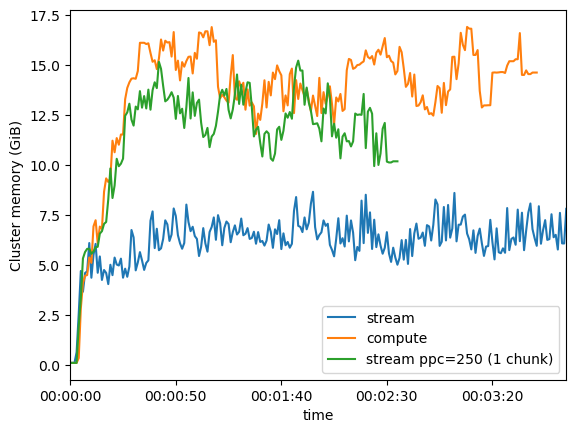

In [11]:
ms.plot(align=True)

In [14]:
ms = MemorySampler()

ppc = [2, 4, 250]
for ppc_val in ppc:
    client.restart()
    gaia_stream = CatalogStream(gaia_first, partitions_per_chunk=ppc_val, shuffle=False)
    with ms.sample(f"stream (ppc={ppc_val})"):
        for i,chunk in enumerate(gaia_stream):
            continue

client.restart()
with ms.sample("compute"):
    gaia_first.compute()

2026-04-08 14:43:49,821 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 6.80 GiB -- Worker memory limit: 11.18 GiB
2026-04-08 14:43:55,140 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 6.89 GiB -- Worker memory limit: 11.18 GiB
2026-04-08 14:46:18,000 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. --

Text(0.5, 1.0, 'Retrieve First Row From 250 Gaia Partitions (2 Workers, 12GB per)')

<Figure size 960x720 with 0 Axes>

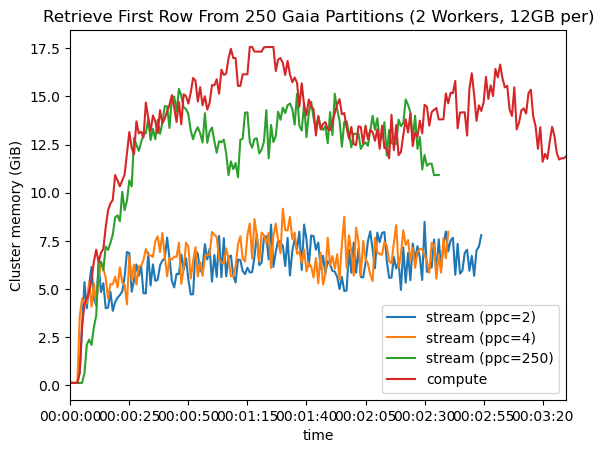

In [37]:
import matplotlib.pyplot as plt
fig = plt.figure(dpi=150)

ms.plot(align=True)
ax = plt.gca()
ax.set_title("Retrieve First Row From 250 Gaia Partitions (2 Workers, 12GB per)")